## KS Curve

### KS Curve (Python – scikit-learn)

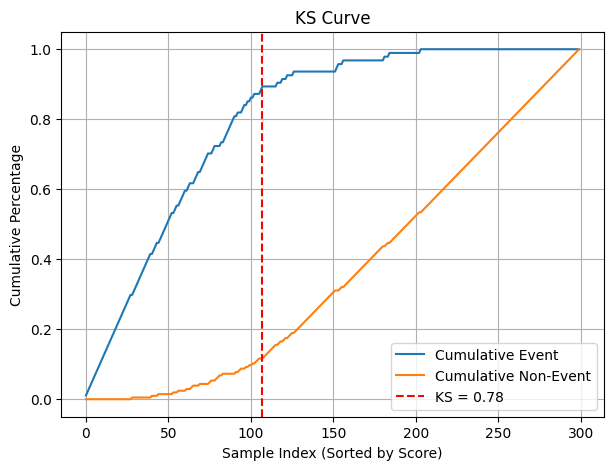

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Generate data
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    weights=[0.7, 0.3],
    random_state=42
)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Create dataframe
df = pd.DataFrame({
    "y_true": y_test,
    "y_prob": y_prob
})

# Sort by probability descending
df = df.sort_values("y_prob", ascending=False).reset_index(drop=True)

# Cumulative distributions
df["cum_event"] = np.cumsum(df["y_true"]) / df["y_true"].sum()
df["cum_non_event"] = np.cumsum(1 - df["y_true"]) / (1 - df["y_true"]).sum()

# KS statistic
df["ks"] = abs(df["cum_event"] - df["cum_non_event"])
ks_value = df["ks"].max()

# Plot KS curve
plt.figure(figsize=(7, 5))
plt.plot(df["cum_event"], label="Cumulative Event")
plt.plot(df["cum_non_event"], label="Cumulative Non-Event")
plt.axvline(df["ks"].idxmax(), linestyle="--", color="red",
            label=f"KS = {ks_value:.2f}")

plt.xlabel("Sample Index (Sorted by Score)")
plt.ylabel("Cumulative Percentage")
plt.title("KS Curve")
plt.legend()
plt.grid()
plt.show()
